In [1]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
from torch import nn
import seaborn as sns
from copy import deepcopy
from utils_plot import *
from run_sim import Config, run_sim, run_sim_wrapper, create_data
from joblib import Parallel, delayed
import shutil
from matplotlib.gridspec import GridSpec

# Run scan_L_A.py to generate the results for Fig2.ipynb


In [3]:
C = Config()

C.G = 0.4
C.linear_net = False
C.learning_rate = 0.0001
C.data_geometry = 'non_linear_fn'
C.L=5
C.print_progress = True
C.length_corridors = [10]*1
C.angle_range = np.pi/10
C.hidden_size = 50 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.MSELoss()

C.s_range = (-1.0, 1.0)
C.num_samples = 1000
C.function_dim = 20
C.discrete_actions = False
C.discrete_samples = False
C.continuous_function = False
C.n_breakpoints = 3
C.action_dist = 'normal'
var_name = 'max_move'
var_values = [0.01, 0.5]
# var_name = 'L'
# var_values = np.arange(1, 10)


In [4]:
# Ensure the results directory exists
results_dir = f'fig_pwlinear_data'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    # if var_value == 1:
    #     C_local.L = 1
    #     C.learning_rate = 0.1
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value) for var_value in var_values
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 996
Input dimension: 21
Output dimension: 20
Function dimension: 20
Action range: [-0.01, 0.01]
Parameter s range: (-1.0, 1.0)
Function type: Piecewise continuous
Number of actions: 1

Sig_2 of last hidden: 2.0671359379775822e-06
Number of samples: 806
Input dimension: 21
Output dimension: 20
Function dimension: 20
Action range: [-0.5, 0.5]
Parameter s range: (-1.0, 1.0)
Function type: Piecewise continuous
Number of actions: 1

Sig_2 of last hidden: 1.8553654399511288e-06


100%|██████████| 10000/10000 [00:41<00:00, 239.85it/s]


max_move: 0.01 --- X shape: torch.Size([996, 21]) --- Number of hidden: 50
max_move: 0.5 --- X shape: torch.Size([806, 21]) --- Number of hidden: 50


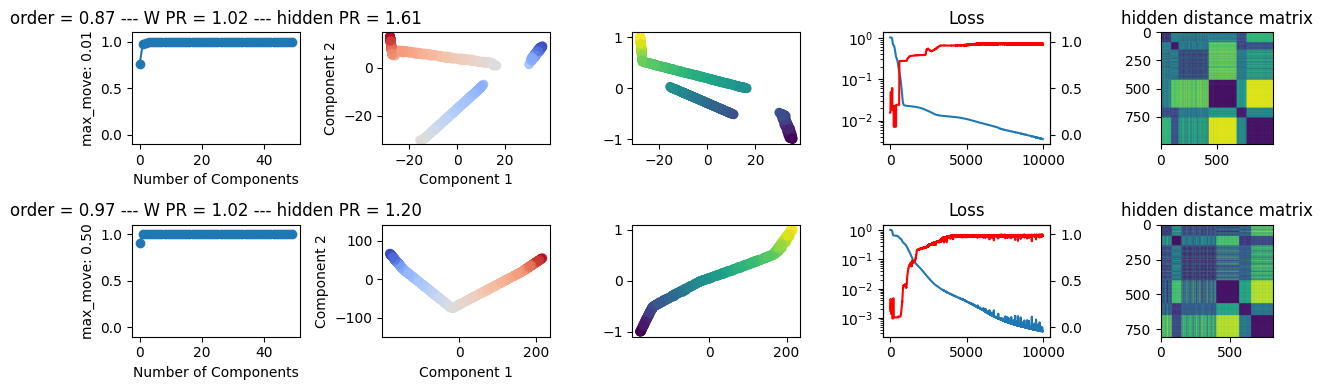

In [5]:
fig, axs = plt.subplots(len(data_dict_l), 5, figsize=(25/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')

In [6]:

def plot_pca_subplot(ax, h, loc_y, cb=False, title=''):
    # PCA to 2D
    from sklearn.decomposition import PCA
    h_pca = PCA(n_components=2).fit_transform(h)
    sc = ax.scatter(
        h_pca[:, 0], h_pca[:, 1], c=loc_y, cmap='coolwarm',
        s=150, alpha=1, edgecolor='none'
    )
    ax.set_title(title, fontsize=20, pad=10)
    ax.axis('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    if cb:
        cbar = plt.colorbar(sc, ax=ax, pad=0.01, fraction=0.05)
        cbar.ax.set_yticklabels([])  # Remove colorbar ticks
        cbar.set_label('location', fontsize=16)

In [7]:
# Set global matplotlib formatting for ICLR paper compatibility
# Set global font to Times New Roman

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
})

import seaborn as sns
sns.set_context("paper")
# sns.set_style("whitegrid")


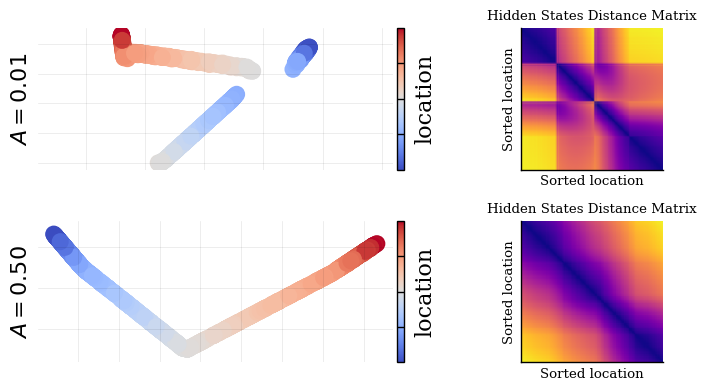

In [29]:
from sklearn.decomposition import PCA

fig, axs = plt.subplots(2, 2, figsize=(8, 4))
axs = axs.flatten()

for i, data_dict in enumerate(data_dict_l):
    hidden = data_dict['hidden_states'][-1].cpu().numpy()
    loc_y = data_dict['loc_y']

    # PCA of hidden states
    pca = PCA(n_components=2)
    hidden_pca = pca.fit_transform(hidden)
    # Add whitegrid background to just this ax
    axs[2*i].grid(True, which='major', axis='both', color='k', linewidth=0.5, alpha=0.1)
    plot_pca_subplot(axs[2*i], hidden_pca, loc_y, cb=True)
    axs[2*i].set_ylabel(f'$A = {getattr(data_dict["C"], var_name):.2f}$', fontsize=16)

    # Distance matrix
    dist_matrix = np.linalg.norm(hidden[:, None, :] - hidden[None, :, :], axis=-1)
    sort_idx = loc_y.argsort()
    dist_matrix_sorted = dist_matrix[sort_idx][:, sort_idx]
    im = axs[2*i+1].imshow(dist_matrix_sorted, aspect='equal', cmap='plasma')
    axs[2*i+1].set_title('Hidden States Distance Matrix')
    axs[2*i+1].set_xlabel('Sorted location')
    axs[2*i+1].set_ylabel('Sorted location')
    axs[2*i+1].set_xticks([])
    axs[2*i+1].set_yticks([])

plt.tight_layout()
fig.savefig('.\final_results\figures\fig_pwlinear.png', dpi=300)